# 02 — GR4J calibration (Differential Evolution baseline)

Conventional single-optimum calibration of GR4J against observed discharge, KGE objective, 730-day warm-up. Baseline for the multimodal (RS-SPSO) study in notebook 03.

In [1]:
import import_ipynb
from Metric_Calculation import compute_KGE, compute_PBIAS, compute_NSE
from GR4J import compute_Q
from scipy.optimize import differential_evolution
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt


30.4 ms ± 460 μs per loop (mean ± std. dev. of 7 runs, 1 loop each)
5.684341886080802e-14
[0.67712195 0.62997907 0.58832275 ... 0.60016149 0.58716065 0.92408118]


In [2]:
csv_path = r"D:\Claude\flood_hydrology_modeling\data\processed\prec_PET_sf.csv"
out_path = r"D:\Claude\flood_hydrology_modeling\data\processed\GR4J.csv"
df = pd.read_csv(csv_path)
P = df['prec_AGCD']
E = df['PET_morton']
obs = df['sf_mmd'].to_numpy(dtype=np.float64)   # keep NaN as-is, don't fill
warmup = 730  # 2-year warm-up (2*365)
x1, x2, x3, x4 = [350, 0, 90, 1.7]
x = np.array((x1,x2,x3,x4))

In [3]:
# Step 2 - the scoring wrapper (warm-up slice + NaN mask, returns KGE):
def score_kge(sim, obs, warmup):
    s = sim[warmup:]
    o = obs[warmup:]
    mask = ~np.isnan(o)
    return compute_KGE(o[mask], s[mask])[0]     # [0] = the KGE scalar
    
# Step 3 - the objective (what scipy minimizes). Return -KGE, with a guard so a bad parameter set can't poison the search with NaN/inf:

def objective(x, P, E, obs, warmup):
    sim = compute_Q(P, E, x)
    kge = score_kge(sim, obs, warmup)
    if not np.isfinite(kge):
        return 1e6           # push optimizer away from bad params
    return -kge
    
# Step 4 - run differential_evolution over the bounds:

bounds = [(1, 1500), (-5, 5), (1, 500), (0.5, 4)]   # x1, x2, x3, x4
result = differential_evolution(
    objective, bounds,
    args=(P, E, obs, warmup),
    seed=42,          # reproducibility - your spec requires stating the seed
    maxiter=300,
    popsize=15,
    tol=1e-6,
    polish=True,      # final local refinement of the best solution
    workers=1,        # keep 1 for now; numba + multiprocessing can clash
)

best = result.x
print("calibrated params x1,x2,x3,x4 =", best)
print("calibration KGE =", -result.fun)

calibrated params x1,x2,x3,x4 = [ 67.56446669   0.54746668 278.14689179   1.00668205]
calibration KGE = 0.8742433125139268


In [4]:
sim = compute_Q(P, E, best)
o = obs[730:]                # observed, after 2-yr warm-up
s = sim[730:]                # simulated, same window
mask = ~np.isnan(o)          # True where obs is a real number, False on the 7 NaN days
o, s = o[mask], s[mask]      # keep only valid days - and keep them aligned
print(compute_KGE(o, s))     # [KGE, r, alpha, beta]
print("NSE   =", compute_NSE(o, s))
print("PBIAS =", compute_PBIAS(o, s))

[0.8742433125139268, 0.8742527044414962, 0.9984790673290138, 1.0002210678684615]
NSE   = 0.7488855957720137
PBIAS = -0.022106786846148127


Text(0, 0.5, 'P (mm/day)')

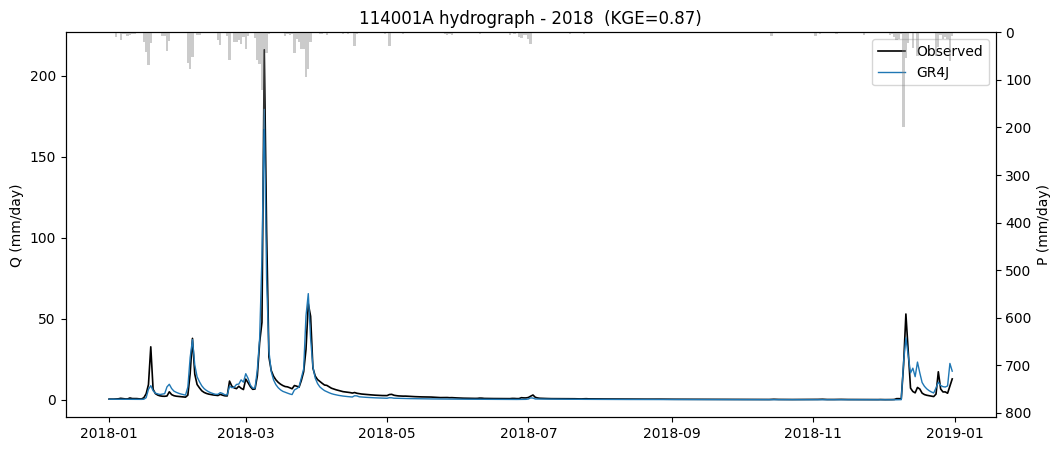

In [5]:
# pick the water-year window around the largest observed event
dates = pd.to_datetime(df['date'])
peak_year = dates.dt.year[int(np.nanargmax(obs))]
m = (dates.dt.year == peak_year)
# Then the plot - observed vs simulated on the same axes:

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(dates[m], obs[m], color='k',        lw=1.2, label='Observed')
ax.plot(dates[m], sim[m], color='tab:blue', lw=1.0, label='GR4J')
ax.set_ylabel('Q (mm/day)')
ax.set_title(f'114001A hydrograph - {peak_year}  (KGE=0.87)')
ax.legend(loc='upper right')
# Optional but worth it for the report - add the rainfall as bars hanging from the top (the classic hydrograph-hyetograph):

ax2 = ax.twinx()
ax2.bar(dates[m], P[m], color='tab:gray', alpha=0.4, width=1)
ax2.set_ylim(P[m].max()*4, 0)     # inverted so bars hang down from the top
ax2.set_ylabel('P (mm/day)')